In [1]:
import numpy as np
from scipy.stats import norm
import os
from scipy.io import loadmat

import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import seaborn as sns
import pandas as pd
import random

In [2]:
class fish_tank(object):
    def __init__(self, n, tank1, tank2, tank3):
        self.n = n
        self.tank1 = tank1 #list# probabilities in tank1 in B-O-G order
        self.tank2 = tank2 #list# probabilities in tank2 in B-O-G order
        self.tank3 = tank3 #list# probabilities in tank3 in B-O-G order
        self.tanks = [self.tank1,self.tank2,self.tank3]
        self.history = []
        self.t = 0
        

        if sum(self.tank1) != 1:
            raise Warning("probabilities in tank1 does not add up to 1")

        if sum(self.tank2) != 1:
            raise Warning("probabilities in tank2 does not add up to 1")

        if sum(self.tank3) != 1:
            raise Warning("probabilities in tank3 does not add up to 1")

    def step(self, tank):
        self.history.append(np.random.choice([0, 1, 2], 1, p = tank)[0])
        self.t = self.t + 1
        
    def reset(self):
        self.history = []
        self.t = 0

    def choose_block(self):
        bl = [0,1,1,1,1,1,1,1,1,2] #10 blocks with # of reversals (1 0 reversal, 8 1 reversals, 1 2 reversal)
        block1 = np.random.permutation(bl)
        block2 = np.random.permutation(bl)
        block3 = np.random.permutation(bl)
        
        blocks = [block1, block2, block3]
        bl = np.random.choice(3)
        return(blocks[bl])
            
    def visualize(self):
        fig, ax = plt.subplots(1,3, figsize = (15,5))
        ax[0].pie(self.tank1, labels=['Blue', 'Orange', 'Green'])
        ax[0].set_title('Tank 1- Fish distribution', fontsize = 12)
        ax[1].pie(self.tank2, labels=['Blue', 'Orange', 'Green'])
        ax[1].set_title('Tank 2- Fish distribution', fontsize = 12)
        ax[2].pie(self.tank3, labels=['Blue', 'Orange', 'Green'])
        ax[2].set_title('Tank 3- Fish distribution', fontsize = 12)

class agent(object):
    def __init__(self, policy = None, **kwargs):
        self.choices = np.array([0, 1, 2])
        self.policy = policy
        
        if self.policy == 'heuristic':
            self.p = kwargs['p']
        elif self.policy == 'RL':
            self.alpha = kwargs['alpha']
            self.tau = kwargs['tau']
        elif self.policy == 'BL':
            self.lmbda = kwargs['lmbda']
            s = (1-self.lmbda)/2
            self.llhood = np.array(([[0,1,1],
                              [1,0,1],
                              [1,1,0]]))*s + np.eye(3)*self.lmbda #each column is initial probs (m,s/2,s/2), (s/2,m,s/2)  etc ..
        else:
            Warning('Select a Policy')

    def iterateTrials_heuristic(self, TANKS_, tank_no, est_prob, trial):
        likelyTank = TANKS_.tanks[tank_no]# probability distributions in the chosen tank
        TANKS_.step(likelyTank)# iterate the shown fish 
        observ = TANKS_.history[trial]## observed fish color
        pred = np.random.choice(self.choices, 1, p = est_prob[trial,:])#agennt makes a prediction

        #prob update
        est_prob[trial+1,observ] = est_prob[trial,observ] + self.p
        est_prob[trial+1,:] = self.compute_prob(est_prob[trial+1,:], option = 'Normalize') #likelihood * prior/ sum(likelihood*prior)
        return(pred, est_prob)

    def iterateTrials_RL(self, TANKS_, tank_no, est_prob, est_value, trial):
        likelyTank = TANKS_.tanks[tank_no]# probability distributions in the chosen tank
        TANKS_.step(likelyTank)# iterate the shown fish 
        pred = np.random.choice(self.choices, 1, p = est_prob[trial,:])
        
        if pred == tank_no:
            reward = 100
        else:
            reward = 0
        #value update with Rescorla-Wagner
        est_value = self.update_vals(est_value, trial, pred, reward)#, option = 'unchanged') ##keeping un-updated entries the same OPTIONS: 1)unchanged 2) update with a reward 1 3) complemntary
        est_prob[trial+1,:] = self.compute_prob(est_value[trial+1,:], option = 'Softmax')
        return(pred, est_prob, est_value)

    def iterateTrials_BL(self, TANKS_, tank_no, est_post, trial):
        likelyTank = TANKS_.tanks[tank_no]# probability distributions in the chosen tank
        TANKS.step(likelyTank)# iterate the shown fish 
        observ = TANKS_.history[trial]## observed fish color
        pred = np.random.choice(self.choices, 1, p = est_post[trial-1,:])[0]
                
        if trial == 0:
            prob = est_post[trial,:] #no prior in the first trial so posterior(t) = prior(t)
        else: 
            prob = est_post[trial-1,:] # prior = posterior(t-1)
                    
        #belief update
        den = np.dot(self.llhood[observ,:], prob) #prob of the data under all the hypothesis
        est_post[trial,:] = np.multiply(self.llhood[observ,:], prob)/den #likelihood * prior/ sum(likelihood*prior)
        
        est_post[trial,:] = np.maximum(0.005, est_post[trial,:]) #we don't want posteiror to get too small and no convergence
        est_post[trial,:] = est_post[trial,:]/est_post[trial,:].sum()
        return(pred, est_post) 

    def compute_prob(self, val, option):#options 1)Normalize 2)softmax
        if option == 'Normalize':
            prob = (val)/(val.sum())
        elif option == 'Softmax':
            prob = (np.exp(val/self.tau))/(np.exp(val/self.tau).sum())
        return(prob)

    def update_vals(self, vals, trial, pred, rwrd):#, option = 'unchanged'):
        #if option == 'unchanged':
        vals[trial+1,:] = vals[trial,:]
        vals[trial+1,pred] = vals[trial,pred] + self.alpha*(rwrd-vals[trial,pred])
        return(vals)

    def initialize_prob(self, n_trials, option = 'Softmax'):
        if self.policy == 'heuristic':
            prob = np.ones((n_trials+1, len(self.choices)))/len(self.choices)
            return(prob)
        
        elif self.policy == 'RL':#reinforcemnet learning Rescorla Wagner
            value = np.zeros((n_trials+1, 3)) #3 choices
            prob = np.zeros((n_trials+1, 3)) 
            value[0,:] = [33,33,33] #make an initial random choice
            prob[0,:] = self.compute_prob(value[0,:], option = option)  ##OPTIIONS: 1) normalization 2) softmax
            return(value, prob)
            
        elif self.policy == 'BL': # Bayesian Learning
            prob = np.ones((n_trials, len(self.choices)))/len(self.choices)#3 is number of fish *POSTERIOR*
            return(prob)
        
                        
def listAppend_wrapper(subjects, blocks, trials, preds, trues, rewards, sources, observeds, name, TANKS_, tank_no, block, trial, pred):
    subjects.append('Subject%d'%name)
    blocks.append(block)
    trials.append(trial)
    preds.append(pred[0])
    trues.append((pred == tank_no)[0])
    rewards.append(100*(pred == tank_no)[0])
    sources.append(tank_no)
    observeds.append(TANKS_.history[trial])
    return(subjects, blocks, trials, preds, trues, rewards, sources, observeds)


def gradient_prob(p_, prob, pred, observ):
    if pred == observ:
        df_lambda_NUM = (1-prob[pred])/(1+p_)
        df_lambda_DEN = 1/(prob[pred]+p_)
        df_lambda = df_lambda_NUM*df_lambda_DEN
    else:
        df_lambda_NUM = 0
        df_lambda_DEN = 1/(1+p_)
        df_lambda = df_lambda_NUM-df_lambda_DEN
    return(df_lambda)

In [3]:
tank1 = [0.8,0.1,0.1] #Probabilities of B-O-G
tank2 = [0.1,0.8,0.1] #Probabilities of B-O-G
tank3 = [0.1,0.1,0.8] #Probabilities of B-O-G

TANKS = fish_tank(3,tank1,tank2,tank3)

# TANKS.visualize()

## GENERATE data with Heuristic with parameters:

In [5]:
nTrials = 15
nSubject = 8

probs_ = np.linspace(0.02,0.98,nSubject)

subjects, blocks, trials, preds, trues, rewards, sources, observeds = [], [], [], [], [], [], [], []

for s in range(nSubject):
    the_block = TANKS.choose_block()
    AGENT = agent(policy = 'heuristic', p = probs_[s])
    
    for b, block in enumerate(the_block):
        prob = AGENT.initialize_prob(nTrials)#intialize posteriors
        if block == 0:
            reversal = 0
            the_tank = np.random.choice(3,1, replace = False) # choose ONE tank to draw fish from
            for i in range(nTrials):
                prediction, prob = AGENT.iterateTrials_heuristic(TANKS, the_tank[0], prob, i)
                subjects, blocks, trials, preds, trues, rewards, sources, observeds = listAppend_wrapper(subjects, blocks, trials, preds, trues, rewards, sources, observeds,
                                                                                                         s, TANKS, the_tank[0], b, i, prediction)
        elif block == 1:
            reversal = np.sort(np.random.randint(low = 1, high = int(nTrials-1), size = (1)))[0]
            the_tank = np.random.choice(3,2, replace = False) # choose TWO tanks to draw fish from
            for i in range(nTrials):
                if  i < reversal:
                    prediction, prob = AGENT.iterateTrials_heuristic(TANKS, the_tank[0], prob, i)
                    subjects, blocks, trials, preds, trues, rewards, sources, observeds = listAppend_wrapper(subjects, blocks, trials, preds, trues, rewards, sources, observeds,
                                                                                                             s, TANKS, the_tank[0], b, i, prediction)
                else:
                    prediction, prob = AGENT.iterateTrials_heuristic(TANKS, the_tank[1], prob, i)
                    subjects, blocks, trials, preds, trues, rewards, sources, observeds = listAppend_wrapper(subjects, blocks, trials, preds, trues, rewards, sources, observeds,
                                                                                                             s, TANKS, the_tank[1], b, i, prediction)
        else:
            reversal = np.sort(np.random.randint(low = 1, high = int(nTrials-1), size = (2)))
            the_tank = np.random.choice(3,3, replace = False) # choose THREE tanks to draw fish from
            for i in range(nTrials):
                if  i < reversal[0]:
                    prediction, prob = AGENT.iterateTrials_heuristic(TANKS, the_tank[0], prob, i)
                    subjects, blocks, trials, preds, trues, rewards, sources, observeds = listAppend_wrapper(subjects, blocks, trials, preds, trues, rewards, sources, observeds,
                                                                                                             s, TANKS, the_tank[0], b, i, prediction)
                elif reversal[0] <= i < reversal[1]:
                    prediction, prob = AGENT.iterateTrials_heuristic(TANKS, the_tank[1], prob, i)
                    subjects, blocks, trials, preds, trues, rewards, sources, observeds = listAppend_wrapper(subjects, blocks, trials, preds, trues, rewards, sources, observeds,
                                                                                                             s, TANKS, the_tank[1], b, i, prediction)
                else:
                    prediction, prob = AGENT.iterateTrials_heuristic(TANKS, the_tank[2], prob, i)
                    subjects, blocks, trials, preds, trues, rewards, sources, observeds = listAppend_wrapper(subjects, blocks, trials, preds, trues, rewards, sources, observeds,
                                                                                                             s, TANKS, the_tank[2], b, i, prediction)
        TANKS.reset()#reset history of every tank after each block

In [6]:
df = pd.DataFrame({'SubjectID':subjects, 'BlockID':blocks, 'TrialID':trials, 'PredLabels':preds, 'Truth':trues, 'Reward':rewards, 'TrueLabels':sources, 'ObservedLabel':observeds})
df.head()

,SubjectID,BlockID,TrialID,PredLabels,Truth,Reward,TrueLabels,ObservedLabel
0,Subject0,0,0,0,True,100,0,2
1,Subject0,0,1,2,False,0,0,1
2,Subject0,0,2,2,False,0,0,0
3,Subject0,0,3,0,True,100,0,0
4,Subject0,0,4,0,True,100,0,1


## implement grid search for the free parameters: paramater fitting

In [8]:
nBlocks = len(the_block)
probs = np.linspace(0,1,501)

iter_errors = np.zeros((nSubject, len(probs)))
best_param = {}

for n in range(nSubject):
    for p, prob in enumerate(probs):
        AGENT = agent(policy = 'heuristic', p = prob)#initialize the artificial agent. ONLY FOR functionality purposes.
        error = np.zeros((nBlocks, nTrials))
        for b in range(nBlocks):
            est_prob = AGENT.initialize_prob(nTrials)
            for i in range(nTrials):
                #get the choices from DF
                pred = df[(df.SubjectID == 'Subject%d'%n)&(df.BlockID == b)&(df.TrialID == i)].PredLabels.to_numpy()[0]
                observ = df[(df.SubjectID =='Subject%d'%n)&(df.BlockID == b)&(df.TrialID == i)].ObservedLabel.to_numpy()[0]
                    
                #prob update
                est_prob[i+1,observ] = est_prob[i,observ] + AGENT.p
                est_prob[i+1,:] = AGENT.compute_prob(est_prob[i+1,:], option = 'Normalize')

                #estimate_error
                error[b,i] = abs(np.log(est_prob[i,pred]))
                    
        iter_errors[n,p] = error.sum()
    p_= np.argmin(iter_errors[n,:])
    best_param['Subject%d'%n]  = probs[p_]

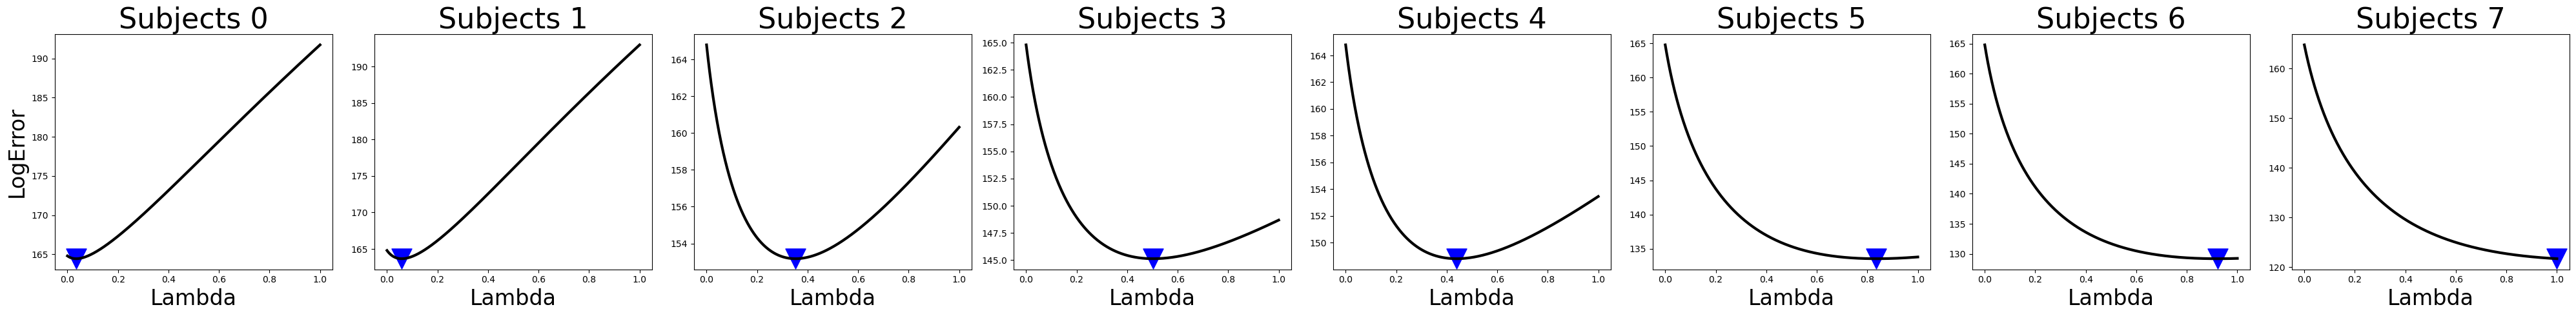

In [9]:
fig,ax = plt.subplots(1, nSubject, figsize = (40,5))
for s in range(nSubject):
    im = ax[s].plot(probs, iter_errors[s,:], c = 'black', lw = 3) 
    ax[s].scatter(best_param['Subject%d'%s], min(iter_errors[s,:]), s = 500, marker = 'v', c = 'blue')
    # ax[s].set_xticks([k*5 for k in range(9)])
    # ax[s].set_yticks([k*0.2 for k in range(6)])        
    ax[0].set_ylabel('LogError', fontsize = 24)
    ax[s].set_title('Subjects %d'%s, fontsize = 32)
    ax[s].set_xlabel('Lambda', fontsize = 24)
    # ax[s].set_ylim(0, iter_errors.max()+50)
plt.tight_layout()

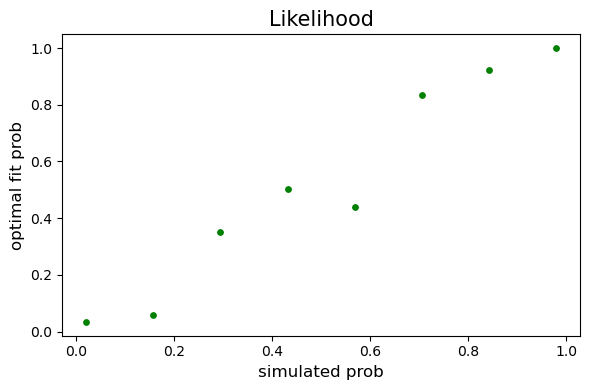

In [10]:
fig, ax = plt.subplots(1,1, figsize = (6,4))
for n in range(nSubject):
    sc = ax.scatter(probs_[n], best_param['Subject%d'%n], s = 15, c = 'green', marker = 'o')
ax.set_xlabel(f'simulated prob', fontsize = 12)
ax.set_ylabel(f'optimal fit prob', fontsize = 12)
ax.set_title('Likelihood', fontsize = 15)


plt.tight_layout()

## implement gradient descent for the free parameters: Parameter fitting

In [12]:
n_iter = 1000
tolerance = 0.000000001
learn_rates = [0.001]
starts = [0.2, 0.9]

iteration_errors = {}
gradient_trajectories = {} 

for n in range(nSubject):
    for l, learn_rate in enumerate(learn_rates):
        for s, start in enumerate(starts):
            iter_error = np.zeros((n_iter))
            grad_traject = np.zeros((n_iter+1))
            grad_traject[0] = start
            vector = grad_traject[0]
            for _ in range(n_iter):
                AGENT = agent(policy = 'heuristic', p = vector)#initialize the artificial agent. ONLY FOR functionality purposes.
                error = np.zeros((nBlocks, nTrials))
                d_prob = 0
                for b in range(nBlocks):
                    est_prob = AGENT.initialize_prob(nTrials)
                    for i in range(nTrials):
                        #get the choices from DF
                        pred = df[(df.SubjectID == 'Subject%d'%n)&(df.BlockID == b)&(df.TrialID == i)].PredLabels.to_numpy()[0]
                        observ = df[(df.SubjectID =='Subject%d'%n)&(df.BlockID == b)&(df.TrialID == i)].ObservedLabel.to_numpy()[0]
                            
                        #prob update
                        est_prob[i+1,observ] = est_prob[i,observ] + AGENT.p
                        est_prob[i+1,:] = AGENT.compute_prob(est_prob[i+1,:], option = 'Normalize')

                        #estimate_error
                        error[b,i] = abs(np.log(est_prob[i,pred]))

                        if i == 0:
                            #gradient
                            d_prob = d_prob + gradient_prob(vector, est_prob[i,:], pred, observ)
                        else:
                            prev_observ = df[(df.SubjectID =='Subject%d'%n)&(df.BlockID == b)&(df.TrialID == i-1)].ObservedLabel.to_numpy()[0]
                            #gradient
                            d_prob = d_prob + gradient_prob(vector, est_prob[i-1,:], pred, prev_observ)
    
                #accumulate all errors
                iter_error[_] = error.sum()
                
                #print(n,l,s,_,diff, vector, iter_error[_])
                diff = learn_rate * d_prob
                if np.all(np.abs(diff) <= tolerance):
                    break
                vector = vector + diff
                grad_traject[_+1] = vector
        
            iteration_errors['%s,%d,%d'%(n,l,s)] = iter_error
            gradient_trajectories['%s,%d,%d'%(n,l,s)] = grad_traject

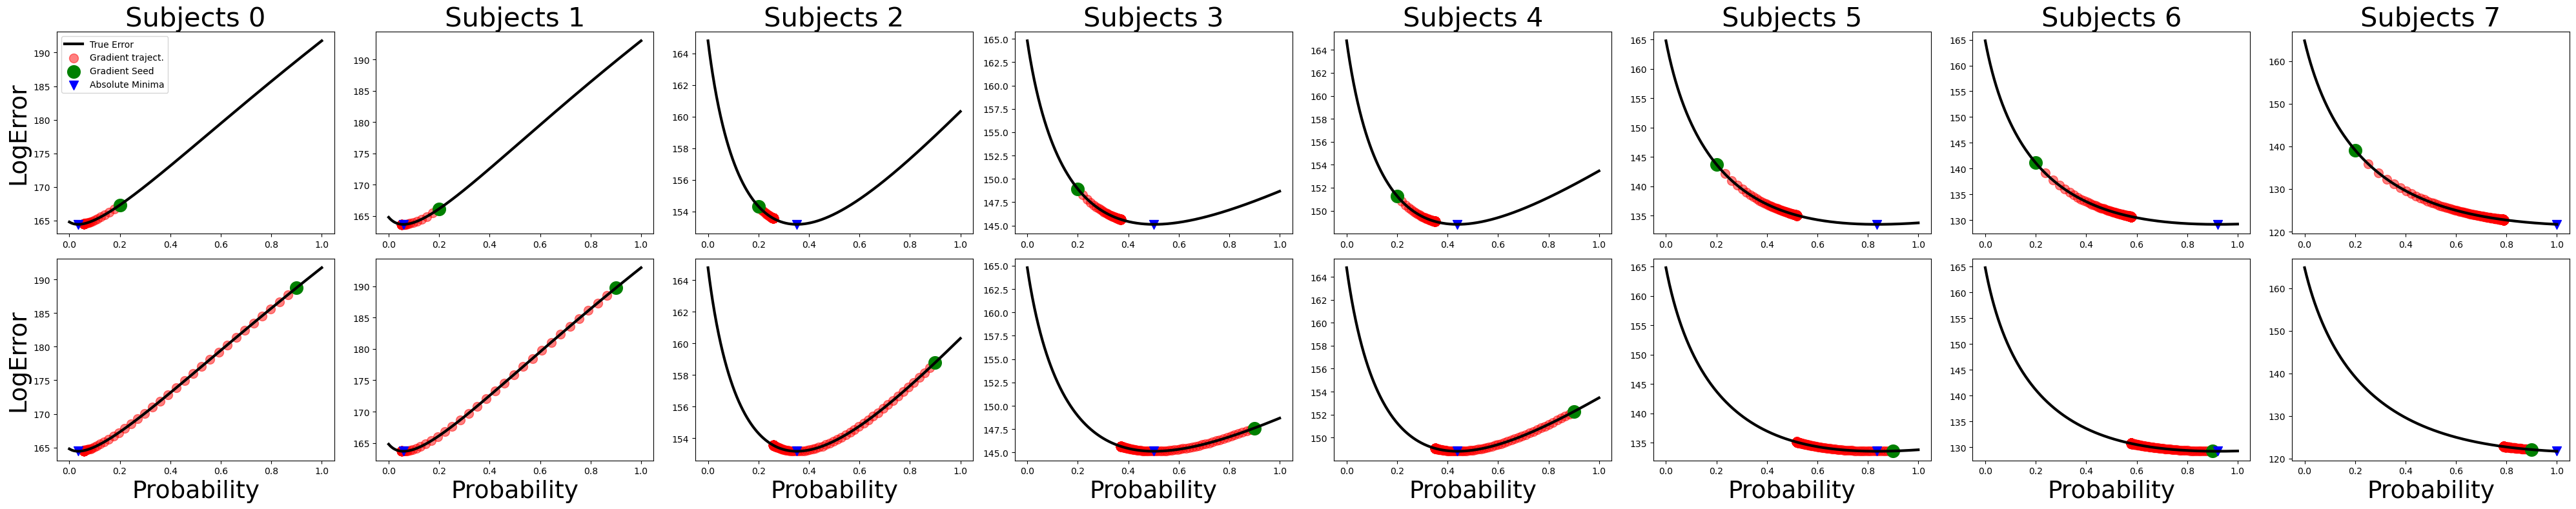

In [13]:
fig,ax = plt.subplots(len(starts), nSubject, figsize = (40,4*len(starts)))
for s in range(nSubject):
    #for l, learn_rate in enumerate(learn_rates):
    l=0
    for start,_ in enumerate(starts):
        im = ax[start][s].plot(probs, iter_errors[s,:], c = 'black', label = 'True Error', lw = 3) 
        
        ax[start][s].scatter(gradient_trajectories['%s,%d,%d'%(s,l,start)][np.nonzero(gradient_trajectories['%s,%d,%d'%(s,l,start)])],
                         iteration_errors['%s,%d,%d'%(s,l,start)][np.nonzero(gradient_trajectories['%s,%d,%d'%(s,l,start)])], label = 'Gradient traject.', s = 100, c = 'red', alpha = 0.5) 
        
        ax[start][s].scatter(_,
                         iteration_errors['%s,%d,%d'%(s,l,start)][0], label = 'Gradient Seed', s = 200, c = 'green', marker = 'o') 

        
        ax[start][s].scatter(best_param['Subject%d'%s], min(iter_errors[s,:]),  label = 'Absolute Minima', s = 100, c = 'blue', marker = 'v') 
       
        ax[start][0].set_ylabel('LogError', fontsize = 27)
    ax[0][s].set_title('Subjects %d'%s, fontsize = 30)
    ax[1][s].set_xlabel('Probability', fontsize = 27)
ax[0][0].legend()
plt.tight_layout()